# MAna.stata - Statistical Testing, Effect Sizes, and Experiments

`MAna.stata` is the statistics layer of MAna. It covers the practical questions that appear after cleaning and visual exploration:

- What does this sample look like?
- Are two groups meaningfully different?
- Is a categorical pattern random or associated with another variable?
- Is the effect large enough to matter?
- How much data do I need before trusting the result?
- What does the frequentist result say, and what does a Bayesian check say?

This notebook uses real datasets from older project work:

- `ab_data.csv` and `countries.csv` from an A/B testing project.
- `googleplaystore.csv` for rating and category inference.
- `stock_markets.xlsx` for numeric relationship examples.

The goal is not to worship p-values. The goal is to turn statistical tools into decisions with assumptions, effect sizes, uncertainty, and context.


## What this module covers

- Descriptive statistics: `descriptive_statistics`, `grouped_descriptive_statistics`, `frequency_table`.
- Associations: `correlation_test`, `partial_correlation`, `correlation_matrix`, `linear_regression_test`.
- Hypothesis tests: `t_test`, `proportion_test`, `chi_square_test`, `mann_whitney_test`, `wilcoxon_test`, `kruskal_wallis_test`, `levene_test`, `normality_test`.
- Experiment workflows: `ABTest`, `MultiVariantTest`, `ABTestResult`.
- Bayesian experiment comparison: `bayesian_proportion_ab_test`.
- Effect sizes and uncertainty: `cohens_d`, `cohens_h`, `confidence_interval_*`, `bootstrap`, `bootstrap_test`.
- Multiple testing correction: `bonferroni_correction`, `holm_bonferroni_correction`, `fdr_correction`, `sidak_correction`.
- Power planning: `two_sample_ttest_power`, `required_sample_size_two_sample`.
- Statistical visualizations: A/B result plots, confidence intervals, lift analysis, funnels, sample size curves, and power curves.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from MAna.data import DataCleaner, read_data
from MAna.stata import (
    ABTest,
    MultiVariantTest,
    absolute_lift,
    bayesian_proportion_ab_test,
    bonferroni_correction,
    bootstrap,
    bootstrap_test,
    chi_square_test,
    cohens_d,
    cohens_h,
    confidence_interval_difference,
    confidence_interval_mean,
    confidence_interval_proportion,
    correlation_matrix,
    correlation_test,
    descriptive_statistics,
    fdr_correction,
    frequency_table,
    grouped_descriptive_statistics,
    holm_bonferroni_correction,
    interpret_effect_size,
    kruskal_wallis_test,
    levene_test,
    linear_regression_test,
    mann_whitney_test,
    normality_test,
    partial_correlation,
    plot_ab_dashboard,
    plot_ab_test_results,
    plot_confidence_intervals,
    plot_conversion_funnel,
    plot_lift_analysis,
    plot_power_curve,
    plot_sample_size_curve,
    plot_sequential_results,
    proportion_test,
    relative_lift,
    required_sample_size_two_sample,
    sidak_correction,
    standardize,
    t_test,
    two_sample_ttest_power,
    wilcoxon_test,
    winsorize,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)

# Keep automated notebook execution quiet. In Jupyter, remove or comment this
# line if you want every matplotlib figure to render inline while running all cells.
RUNNING_IN_NOTEBOOK = "get_ipython" in globals()
if not RUNNING_IN_NOTEBOOK:
    plt.show = lambda *args, **kwargs: None


## 1. Load real datasets with MAna.data

Statistics examples need real variation, real imbalance, and real mess. We load the datasets with `read_data()` and use `DataCleaner` only for the obvious structural cleanup. The statistical preparation stays visible because each cleaning choice affects the inference.


In [2]:
# Paths work from either docs/notebooks or the repo root.
ab_path = Path("data/ab_data.csv")
countries_path = Path("data/countries.csv")
playstore_path = Path("data/googleplaystore.csv")
stock_path = Path("data/stock_markets.xlsx")

if not ab_path.exists():
    ab_path = Path("docs/notebooks/data/ab_data.csv")
    countries_path = Path("docs/notebooks/data/countries.csv")
    playstore_path = Path("docs/notebooks/data/googleplaystore.csv")
    stock_path = Path("docs/notebooks/data/stock_markets.xlsx")

ab_raw = read_data(ab_path)
countries = read_data(countries_path)
playstore_raw = read_data(playstore_path)
stocks_raw = read_data(stock_path)

{
    "ab_raw": ab_raw.shape,
    "countries": countries.shape,
    "playstore_raw": playstore_raw.shape,
    "stocks_raw": stocks_raw.shape,
}


{'ab_raw': (294478, 5),
 'countries': (290584, 2),
 'playstore_raw': (10841, 13),
 'stocks_raw': (2126, 2)}

In [3]:
# A/B data hygiene:
# 1. Keep only rows where the assigned group matches the page actually shown.
# 2. Drop duplicate users, because an experiment unit should be counted once.
# 3. Join country so we can later demonstrate multi-variant/categorical analysis.
ab = ab_raw.merge(countries, on="user_id", how="left")
ab = ab[
    ((ab["group"].eq("control")) & (ab["landing_page"].eq("old_page")))
    | ((ab["group"].eq("treatment")) & (ab["landing_page"].eq("new_page")))
].copy()
ab = ab.sort_values("timestamp")
ab = (
    DataCleaner(ab, verbose=False)
    .remove_duplicates(subset=["user_id"], keep="first")
    .parse_dates(columns=["timestamp"], extract_features=False)
    .coerce_numeric(columns=["converted"])
    .fix_missing_values(strategy={"country": "mode"})
    .drop_missing_rows(subset=["user_id", "timestamp", "converted"])
    .get_cleaned_data()
)

# Google Play data hygiene:
# Ratings are numeric, reviews/installs need parsing, and the invalid category row
# in this public dataset should be removed before statistical tests.
playstore = playstore_raw.copy()
playstore["Installs Clean"] = (
    playstore["Installs"].astype(str).str.replace("+", "", regex=False).str.replace(",", "", regex=False)
)
playstore["Price Clean"] = playstore["Price"].astype(str).str.replace("$", "", regex=False)
playstore = (
    DataCleaner(playstore, verbose=False)
    .coerce_numeric(columns=["Rating", "Reviews", "Installs Clean", "Price Clean"])
    .drop_missing_rows(subset=["Rating", "Category", "Type", "Reviews", "Installs Clean"])
    .remove_duplicates()
    .get_cleaned_data()
)
playstore = playstore[playstore["Rating"].between(1, 5)].copy()

# Stock data is already tidy. Keep numeric returns for association examples.
stocks = (
    DataCleaner(stocks_raw, verbose=False)
    .parse_dates(columns=["Date"], extract_features=False)
    .coerce_numeric(columns=["Close"])
    .drop_missing_rows(subset=["Date", "Close"])
    .remove_duplicates()
    .get_cleaned_data()
    .sort_values("Date")
)
stocks["daily_return"] = stocks["Close"].pct_change()
stocks["rolling_7d_return"] = stocks["Close"].pct_change(7)
stocks["rolling_30d_volatility"] = stocks["daily_return"].rolling(30).std()

ab.shape, playstore.shape, stocks.shape


((290584, 6), (8892, 15), (2126, 5))

## 2. Descriptive statistics before inference

Before any test, inspect sample size, center, spread, missingness, and group balance. Statistical tests are not a replacement for understanding the data shape.


In [4]:
# descriptive_statistics(): robust one-sample summary with finite-value filtering.
# Here we summarize app ratings after parsing and cleaning.
rating_summary = descriptive_statistics(playstore["Rating"])
pd.DataFrame([rating_summary]).T.rename(columns={0: "rating_summary"})


,rating_summary
count,8892
excluded,0
mean,4.187877
median,4.3
mode,4.4
modes,[4.4]
mode_count,1032
minimum,1.0
maximum,5.0
range,4.0


In [5]:
# grouped_descriptive_statistics(): compare the same numeric signal by groups.
# We keep the top app categories so the table stays readable.
top_categories = playstore["Category"].value_counts().head(8).index
rating_by_category = grouped_descriptive_statistics(
    playstore[playstore["Category"].isin(top_categories)],
    value_column="Rating",
    group_columns="Category",
).sort_values("mean", ascending=False)

rating_by_category

,Category,count,mean,median,standard_deviation,minimum,q1,q3,maximum,iqr
6,PERSONALIZATION,310,4.333871,4.4,0.353962,2.5,4.2,4.6,5.0,0.4
3,GAME,1074,4.281285,4.3,0.367117,1.0,4.1,4.5,5.0,0.4
7,PRODUCTIVITY,334,4.201796,4.3,0.514472,1.0,4.1,4.5,5.0,0.4
4,FAMILY,1718,4.191153,4.3,0.511217,1.0,4.0,4.5,5.0,0.5
0,COMMUNICATION,307,4.151466,4.3,0.438383,1.0,4.0,4.4,5.0,0.4
1,FINANCE,317,4.127445,4.3,0.647026,1.0,4.0,4.5,5.0,0.5
2,LIFESTYLE,305,4.096066,4.2,0.701960,1.5,3.8,4.6,5.0,0.8
5,TOOLS,734,4.047411,4.2,0.616143,1.0,3.8,4.4,5.0,0.6


In [6]:
# frequency_table(): counts, proportions, percentages, and cumulative percentage.
# This is useful for experiment balance and categorical data checks.
frequency_table(ab["group"])

,value,count,proportion,percentage,cumulative_percentage
0,treatment,145310,0.500062,50.006194,50.006194
1,control,145274,0.499938,49.993806,100.000000


## 3. A/B testing from raw experiment data

`ABTest` is the high-level workflow: give it a DataFrame, a variant column, and a metric column. For binary metrics such as conversion, it automatically uses a two-sample proportion test and returns lift, confidence intervals, p-value, effect size, sample sizes, and a recommendation.


In [7]:
ab.converted.value_counts()

converted
0    255831
1     34753
Name: count, dtype: int64

In [8]:
ab.landing_page.value_counts()

landing_page
new_page    145310
old_page    145274
Name: count, dtype: int64

In [9]:
ab.group.value_counts()

group
treatment    145310
control      145274
Name: count, dtype: int64

In [10]:
# turning the landing page into a binary metric for conversion rate analysis.
ab["landing_page"] = ab["landing_page"].map({"old_page": 0, "new_page": 1})

In [11]:
# ABTest(): raw experiment data -> decision-ready result object.
# Use verbose=False in documentation so the notebook displays clean tables instead
# of long terminal-style text blocks.
ab_test = ABTest(
    data=ab,
    variant_col="group",
    metric_col="converted",
    control_name="control",
    treatment_name="treatment",
    metric_name="conversion_rate",
    metric_type="binary",
    alpha=0.05,
)

ab_result = ab_test.run(verbose=False)
ab_result.to_dataframe().T.rename(columns={0: "ab_result"})

,ab_result
test_name,A/B Test: conversion_rate
control_name,control
treatment_name,treatment
metric_name,conversion_rate
metric_type,binary
control_metric,0.120386
treatment_metric,0.118808
control_ci,"(0.11872297704421186, 0.12206970756307128)"
treatment_ci,"(0.11715449706961521, 0.12048178803682728)"
p_value,0.189883


In [12]:
# The same question can be asked directly from summary counts.
# This is handy when a dashboard or analytics warehouse gives aggregate counts only.
summary_counts = ab.groupby("group")["converted"].agg(successes="sum", trials="count")
summary_proportion_test = proportion_test(
    successes1=int(summary_counts.loc["control", "successes"]),
    n1=int(summary_counts.loc["control", "trials"]),
    successes2=int(summary_counts.loc["treatment", "successes"]),
    n2=int(summary_counts.loc["treatment", "trials"]),
    alternative="two-sided",
)

pd.DataFrame([summary_proportion_test.to_dict()]).T.rename(columns={0: "proportion_test"})


,proportion_test
test_name,Two-Sample Proportion Z-Test
statistic,1.310924
p_value,0.189883
significant,False
alpha,0.05
effect_size,0.004864
effect_size_name,Cohen's h
confidence_interval,"(-0.0007813822743416229, 0.003937860245052736)"
sample_sizes,"{'group_1': 145274, 'group_2': 145310}"
descriptive_stats,"{'Group 1': {'successes': 17489, 'total': 145274, 'proportion': 0.1203863045004612, 'percentage'..."


In [13]:
# Utility helpers expose the practical change directly.
control_rate = ab_result.control_metric
treatment_rate = ab_result.treatment_metric

pd.DataFrame(
    {
        "metric": ["control_rate", "treatment_rate", "absolute_lift", "relative_lift_%", "cohens_h"],
        "value": [
            control_rate,
            treatment_rate,
            absolute_lift(control_rate, treatment_rate),
            relative_lift(control_rate, treatment_rate),
            cohens_h(control_rate, treatment_rate),
        ],
    }
)


,metric,value
0,control_rate,0.120386
1,treatment_rate,0.118808
2,absolute_lift,-0.001578
3,relative_lift_%,-1.310979
4,cohens_h,0.004864


## 4. Bayesian A/B check

A frequentist p-value answers one question. A Bayesian comparison answers another: given the observed data and prior, how likely is B to be better than A? This is often easier to explain to business users, but it still depends on assumptions.


In [14]:
# bayesian_proportion_ab_test(): beta-binomial comparison for conversion rates.
# The default Beta(1, 1) prior is uniform. Increase samples for a smoother Monte
# Carlo estimate; keep a random_state for reproducible documentation.
bayesian_result = bayesian_proportion_ab_test(
    successes_a=int(summary_counts.loc["control", "successes"]),
    trials_a=int(summary_counts.loc["control", "trials"]),
    successes_b=int(summary_counts.loc["treatment", "successes"]),
    trials_b=int(summary_counts.loc["treatment", "trials"]),
    samples=50_000,
    random_state=42,
)

pd.DataFrame([bayesian_result]).T.rename(columns={0: "bayesian_result"})


,bayesian_result
rate_a,0.120386
rate_b,0.118808
posterior_mean_a,0.120392
posterior_mean_b,0.118813
posterior_interval_a,"(0.11872311701908468, 0.12206984386790648)"
posterior_interval_b,"(0.1171546376572532, 0.12048192480823941)"
probability_b_better,0.09568
probability_a_better,0.90432
expected_difference,-0.001578
difference_credible_interval,"(-0.003941996425724397, 0.0007820861636111002)"


## 5. Categorical tests and country segments

Categorical tests help answer questions such as: is conversion independent of country, or do some countries convert differently? Use this with caution in experiments because segment analysis can multiply false positives quickly.


In [15]:
# chi_square_test(): independence test on a contingency table.
# Rows are countries, columns are converted/not converted.
country_conversion_table = pd.crosstab(ab["country"], ab["converted"])
chi_result = chi_square_test(country_conversion_table)

pd.DataFrame([chi_result.to_dict()]).T.rename(columns={0: "country_conversion_chi_square"})


,country_conversion_chi_square
test_name,Chi-Square Test of Independence
statistic,3.21057
p_value,0.200832
significant,False
alpha,0.05
effect_size,0.003324
effect_size_name,Cramér's V
confidence_interval,"(0, 7.130570465295243)"
sample_sizes,{'total': 290584}
descriptive_stats,"{'Observed Table': [[12827, 1672], [63727, 8739], [179277, 24342]], 'Expected Table': [[12764.96..."


In [16]:
# MultiVariantTest(): compare several variants to a control.
# To demonstrate multi-variant behavior on real data, we create country-specific
# treatment labels and compare them against the global control group.
country_experiment = ab.copy()
country_experiment["variant_country"] = np.where(
    country_experiment["group"].eq("control"),
    "control",
    "treatment_" + country_experiment["country"].astype(str),
)

multi_test = MultiVariantTest(
    data=country_experiment,
    variant_col="variant_country",
    metric_col="converted",
    control_name="control",
    metric_type="binary",
    metric_name="conversion_rate",
    correction_method="holm",
)
multi_results = multi_test.run(verbose=False)
multi_test.summary

,variant,metric,ci_lower,ci_upper,relative_lift_%,absolute_lift,p_value,significant,winner
1,treatment_UK,0.121171,0.117845,0.124577,0.651812,0.000785,0.681926,False,
0,treatment_US,0.118466,0.116496,0.120464,-1.595451,-0.001921,0.294901,False,
2,treatment_CA,0.111902,0.104874,0.119339,-7.047168,-0.008484,0.088469,False,


## 6. Continuous metrics: assumptions, t-tests, and non-parametric alternatives

For app ratings, we can compare free and paid apps. Ratings are bounded and often non-normal, so the notebook checks normality and variance assumptions, then compares both a Welch-style t-test and a non-parametric Mann-Whitney test.


In [17]:
# Build two rating samples. Downsample the larger group so assumption checks and
# plots stay quick while still using real observations.
free_ratings = playstore.loc[playstore["Type"].eq("Free"), "Rating"].dropna().sample(1000, random_state=7)
paid_ratings = playstore.loc[playstore["Type"].eq("Paid"), "Rating"].dropna()

{
    "free_n": len(free_ratings),
    "paid_n": len(paid_ratings),
    "free_mean": free_ratings.mean(),
    "paid_mean": paid_ratings.mean(),
}


{'free_n': 1000,
 'paid_n': 613,
 'free_mean': 4.167200000000001,
 'paid_mean': 4.261500815660685}

In [18]:
# normality_test(): small p-values mean the sample departs from normality.
# For large samples this can be sensitive, so combine it with plots/effect sizes.
normality_free = normality_test(free_ratings, method="shapiro")
normality_paid = normality_test(paid_ratings, method="shapiro")
levene_result = levene_test(free_ratings, paid_ratings, center="median")

pd.DataFrame(
    [
        {"check": "free normality", **normality_free.to_dict()},
        {"check": "paid normality", **normality_paid.to_dict()},
        {"check": "equal variances", **levene_result.to_dict()},
    ]
)[["check", "test_name", "statistic", "p_value", "significant", "recommendation"]]


,check,test_name,statistic,p_value,significant,recommendation
0,free normality,Shapiro-Wilk Normality Test,0.866883,2.627242e-28,True,Reject the null hypothesis of normality. The data is NOT normally distributed. Consider using no...
1,paid normality,Shapiro-Wilk Normality Test,0.840878,2.733600e-24,True,Reject the null hypothesis of normality. The data is NOT normally distributed. Consider using no...
2,equal variances,Levene's Test for Equality of Variances,0.032800,8.563069e-01,False,Fail to reject the null hypothesis of equal variances. Standard t-test or ANOVA with equal varia...


In [19]:
# t_test(): compare group means.
# equal_var=False chooses Welch's t-test, which is safer when spreads differ.
rating_ttest = t_test(free_ratings, paid_ratings, equal_var=False)
rating_mann_whitney = mann_whitney_test(free_ratings, paid_ratings)

pd.DataFrame(
    [
        {"method": "Welch-style t-test", **rating_ttest.to_dict()},
        {"method": "Mann-Whitney", **rating_mann_whitney.to_dict()},
    ]
)[["method", "test_name", "statistic", "p_value", "effect_size", "effect_size_name", "significant", "recommendation"]]


,method,test_name,statistic,p_value,effect_size,effect_size_name,significant,recommendation
0,Welch-style t-test,Welch's T-Test (Unequal Variances),-3.332943,8.841032e-04,-0.172035,Cohen's d,True,Reject the null hypothesis. There is sufficient evidence of a difference. The effect size sugges...
1,Mann-Whitney,Mann-Whitney U Test,260436.000000,3.574775e-07,0.150290,Rank-biserial correlation (r),True,Reject the null hypothesis. Group 2 has a significantly higher median. The effect size suggests ...


In [20]:
# Effect size and confidence interval are what make the result interpretable.
# A tiny p-value with a tiny effect may not deserve a product decision.
rating_effect = cohens_d(free_ratings, paid_ratings, correction=True)
rating_ci = confidence_interval_difference(free_ratings, paid_ratings, equal_var=False)

pd.DataFrame(
    {
        "quantity": ["cohens_d_hedges_corrected", "effect_size_interpretation", "mean_difference_ci"],
        "value": [rating_effect, interpret_effect_size(rating_effect, "cohens_d"), rating_ci],
    }
)


,quantity,value
0,cohens_d_hedges_corrected,-0.171954
1,effect_size_interpretation,negligible
2,mean_difference_ci,"(-0.1498081287965893, -0.03879350252477768)"


## 7. Paired and multi-group examples

Some tests need paired observations, and some compare more than two groups. The stock series gives natural paired before/after style examples; app categories give multi-group rating comparisons.


In [21]:
# wilcoxon_test(): paired non-parametric comparison.
# Compare 7-day rolling returns before and after winsorization. This is a compact
# way to show paired input mechanics on real financial-style data.
returns = stocks["rolling_7d_return"].dropna().to_numpy()
returns_sample = returns[:300]
winsorized_returns = np.asarray(winsorize(returns_sample, limits=(0.05, 0.05)), dtype=float)
wilcoxon_result = wilcoxon_test(returns_sample, winsorized_returns)

pd.DataFrame([wilcoxon_result.to_dict()]).T.rename(columns={0: "wilcoxon_result"})


,wilcoxon_result
test_name,Wilcoxon Signed-Rank Test
statistic,213.0
p_value,0.688359
significant,False
alpha,0.05
effect_size,-0.858568
effect_size_name,Effect size (r)
confidence_interval,None
sample_sizes,{'paired_samples': 300}
descriptive_stats,"{'Group 1': {'median': -0.0035606862280021523, 'mean': -0.0006688667755444773, 'n': 300}, 'Group..."


In [22]:
# kruskal_wallis_test(): compare 3+ groups when normality is questionable.
# Here we compare ratings across the largest app categories.
category_groups = [
    playstore.loc[playstore["Category"].eq(category), "Rating"].dropna().sample(
        min(300, playstore["Category"].eq(category).sum()),
        random_state=7,
    )
    for category in top_categories[:5]
]
kruskal_result = kruskal_wallis_test(*category_groups)

pd.DataFrame([kruskal_result.to_dict()]).T.rename(columns={0: "kruskal_result"})


,kruskal_result
test_name,Kruskal-Wallis H-Test
statistic,36.476264
p_value,0.0
significant,True
alpha,0.05
effect_size,0.021723
effect_size_name,Epsilon squared (ε²)
confidence_interval,None
sample_sizes,"{'group_1': 300, 'group_2': 300, 'group_3': 300, 'group_4': 300, 'group_5': 300}"
descriptive_stats,"{'Group 1': {'median': 4.2, 'mean': 4.146999999999999, 'q1': 3.9, 'q3': 4.5, 'n': 300}, 'Group 2..."


## 8. Associations and simple regression

Association helpers answer relationship questions. `correlation_test()` provides p-values for Pearson/Spearman/Kendall. `partial_correlation()` is useful when a third variable explains both variables. `linear_regression_test()` gives a simple inferential line.


In [23]:
# Correlation between app reviews and installs is usually strong but non-linear.
# Spearman correlation is a better default here because both variables are skewed.
app_volume = playstore[["Reviews", "Installs Clean", "Rating"]].replace([np.inf, -np.inf], np.nan).dropna()
app_volume["log_reviews"] = np.log1p(app_volume["Reviews"])
app_volume["log_installs"] = np.log1p(app_volume["Installs Clean"])

spearman_result = correlation_test(app_volume["log_reviews"], app_volume["log_installs"], method="spearman")
pearson_matrix = correlation_matrix(app_volume[["Rating", "log_reviews", "log_installs"]])

spearman_result, pearson_matrix


({'method': 'spearman',
  'n': 8892,
  'coefficient': 0.9635894346687854,
  'p_value': 0.0,
  'alpha': 0.05,
  'significant': True,
  'decision': 'reject_null'},
                 Rating  log_reviews  log_installs
 Rating        1.000000     0.207851      0.114894
 log_reviews   0.207851     1.000000      0.956684
 log_installs  0.114894     0.956684      1.000000)

In [24]:
# partial_correlation(): control for Rating while checking Reviews vs Installs.
partial_result = partial_correlation(
    app_volume,
    x="log_reviews",
    y="log_installs",
    covariates="Rating",
)

# linear_regression_test(): simple regression diagnostics for a two-variable line.
regression_result = linear_regression_test(app_volume["log_reviews"], app_volume["log_installs"])

pd.DataFrame([partial_result, regression_result], index=["partial_correlation", "linear_regression"])


,x,y,covariates,n,degrees_of_freedom,coefficient,p_value,alpha,significant,decision,slope,intercept,r_value,r_squared,slope_standard_error,intercept_standard_error
partial_correlation,log_reviews,log_installs,[Rating],8892,8889.0,0.959987,0.0,0.05,True,reject_null,NaN,NaN,NaN,NaN,NaN,NaN
linear_regression,NaN,NaN,NaN,8892,NaN,NaN,0.0,0.05,True,reject_null,0.955162,4.292518,0.956684,0.915244,0.003083,0.028077


## 9. Bootstrap, robust scaling, and multiple testing correction

Bootstrap methods are useful when you do not want to lean fully on parametric assumptions. Multiple-testing corrections protect you when you test many categories, countries, or variants.


In [25]:
# bootstrap(): estimate uncertainty around a statistic by resampling.
bootstrap_median_rating = bootstrap(
    playstore["Rating"].dropna(),
    statistic=np.median,
    n_bootstrap=2000,
    random_state=7,
)

# bootstrap_test(): permutation-style group comparison.
bootstrap_rating_test = bootstrap_test(
    free_ratings,
    paid_ratings,
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    n_bootstrap=2000,
    random_state=7,
)

pd.DataFrame(
    [
        {"name": "median_rating_bootstrap", "estimate": bootstrap_median_rating["statistic"], "ci": bootstrap_median_rating["ci"], "std": bootstrap_median_rating["std"]},
        {"name": "free_minus_paid_rating_test", "estimate": bootstrap_rating_test["observed_statistic"], "p_value": bootstrap_rating_test["p_value"]},
    ]
)


,name,estimate,ci,std,p_value
0,median_rating_bootstrap,4.300000,"(4.3, 4.3)",1.776357e-15,NaN
1,free_minus_paid_rating_test,-0.094301,NaN,NaN,0.0005


In [26]:
# standardize() and winsorize(): small transformation helpers.
# Use these for modeling/prep or robust sensitivity checks, not to hide inconvenient data.
standardized_reviews = standardize(app_volume["log_reviews"], method="zscore")
robust_installs = standardize(app_volume["log_installs"], method="robust")

pd.DataFrame(
    {
        "transformed_signal": ["standardized_log_reviews", "robust_log_installs"],
        "mean": [np.mean(standardized_reviews), np.mean(robust_installs)],
        "std": [np.std(standardized_reviews, ddof=1), np.std(robust_installs, ddof=1)],
    }
)


,transformed_signal,mean,std
0,standardized_log_reviews,-5.114118e-17,1.000000
1,robust_log_installs,-1.514399e-01,0.616801


In [27]:
# Multiple testing correction on country-specific A/B comparisons.
country_p_values = multi_test.summary["p_value"].to_numpy(dtype=float)
bonferroni_p, bonferroni_alpha = bonferroni_correction(country_p_values)
holm_reject, holm_p = holm_bonferroni_correction(country_p_values)
fdr_reject, fdr_p = fdr_correction(country_p_values)
sidak_p, sidak_alpha = sidak_correction(country_p_values)

pd.DataFrame(
    {
        "variant": multi_test.summary["variant"].to_numpy(),
        "raw_p": country_p_values,
        "bonferroni_p": bonferroni_p,
        "holm_p": holm_p,
        "holm_reject": holm_reject,
        "fdr_p": fdr_p,
        "fdr_reject": fdr_reject,
        "sidak_p": sidak_p,
    }
).sort_values("raw_p")


,variant,raw_p,bonferroni_p,holm_p,holm_reject,fdr_p,fdr_reject,sidak_p
2,treatment_CA,0.088469,0.265408,0.265408,False,0.265408,False,0.24262
1,treatment_US,0.294901,0.884704,0.589802,False,0.442352,False,0.64945
0,treatment_UK,0.681926,1.000000,0.681926,False,0.681926,False,0.96782


## 10. Power and sample-size planning

Power analysis belongs before the experiment whenever possible. It helps prevent underpowered tests that end with "nothing happened" only because the sample was too small.


In [28]:
# two_sample_ttest_power(): achieved power for a planned effect size and sample size.
# required_sample_size_two_sample(): smallest per-group n for a target power.
for_effect_size = 0.20
required_n = required_sample_size_two_sample(for_effect_size, power=0.80, alpha=0.05)
achieved_power = two_sample_ttest_power(for_effect_size, required_n, alpha=0.05)

pd.DataFrame(
    {
        "quantity": ["effect_size", "required_n_per_group", "achieved_power"],
        "value": [for_effect_size, required_n, achieved_power],
    }
)


,quantity,value
0,effect_size,0.200000
1,required_n_per_group,394.000000
2,achieved_power,0.800593


## 11. Statistical visualizations

The plotting helpers are designed for communication after the statistical result exists. In automated documentation checks, `plt.show()` is suppressed; in Jupyter, comment out that suppression if you want every chart to render while running all cells.


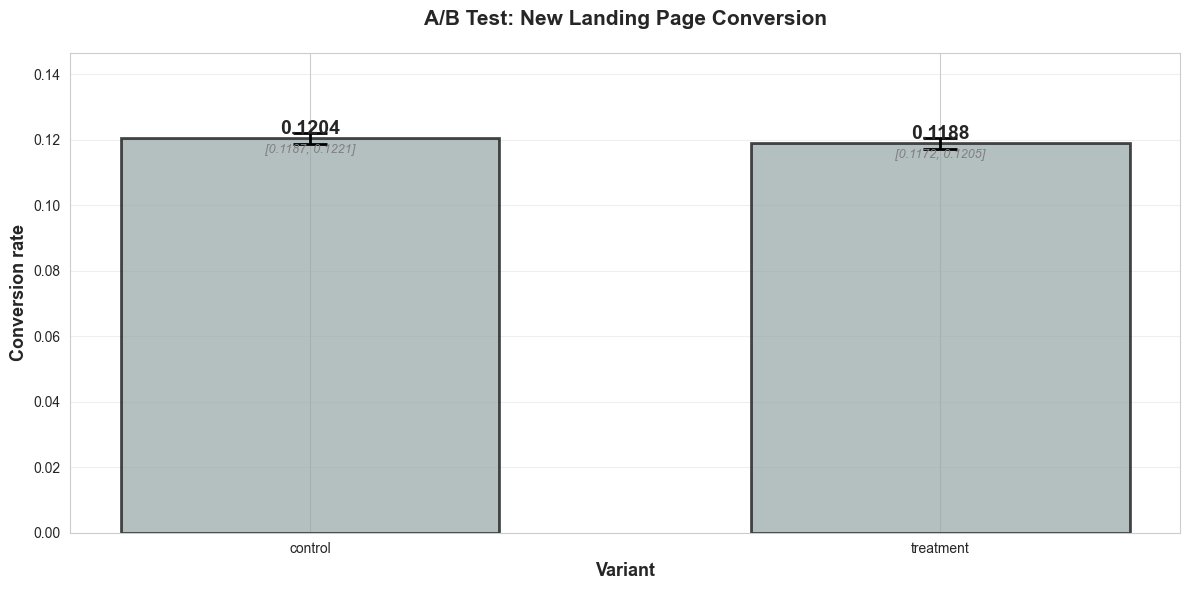

In [29]:
# plot_ab_test_results(): variant metrics with confidence intervals.
fig = plot_ab_test_results(
    control_metric=ab_result.control_metric,
    treatment_metric=ab_result.treatment_metric,
    control_ci=ab_result.control_ci,
    treatment_ci=ab_result.treatment_ci,
    control_name="control",
    treatment_name="treatment",
    metric_name="Conversion rate",
    p_value=ab_result.p_value,
    significant=ab_result.significant,
    title="A/B Test: New Landing Page Conversion",
)


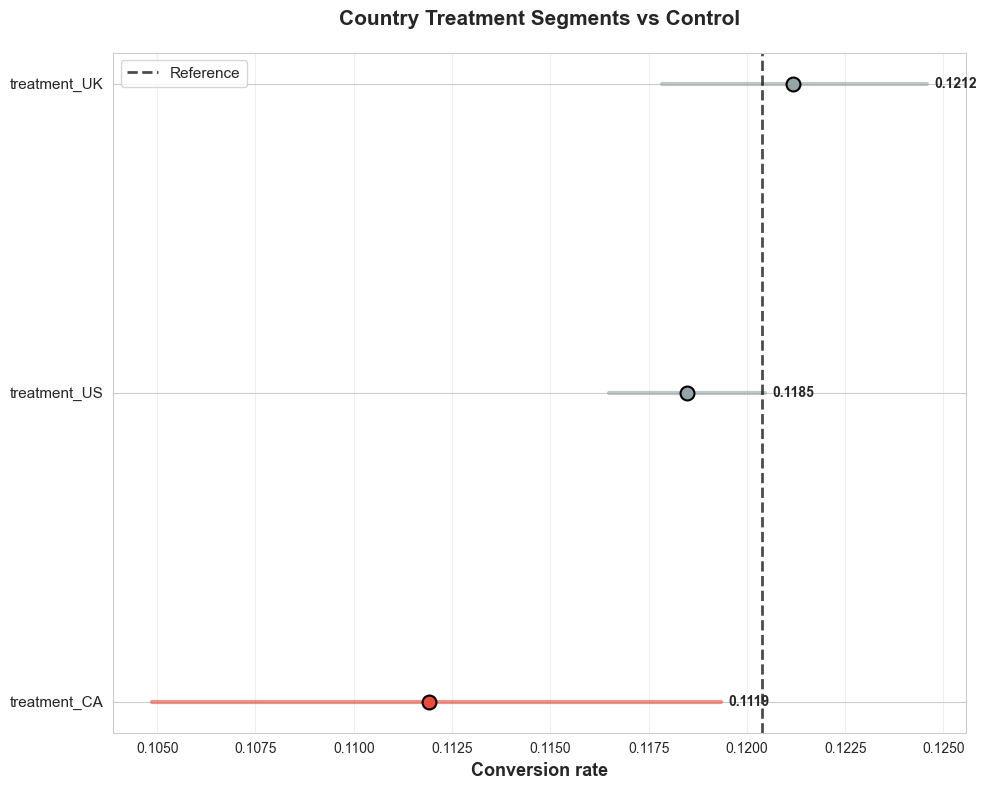

In [30]:
# plot_confidence_intervals(): forest-style comparison across variants or segments.
ci_frame = multi_test.summary.copy()
fig = plot_confidence_intervals(
    metrics=ci_frame["metric"].tolist(),
    ci_lower=ci_frame["ci_lower"].tolist(),
    ci_upper=ci_frame["ci_upper"].tolist(),
    labels=ci_frame["variant"].tolist(),
    metric_name="Conversion rate",
    reference_line=ab_result.control_metric,
    title="Country Treatment Segments vs Control",
)


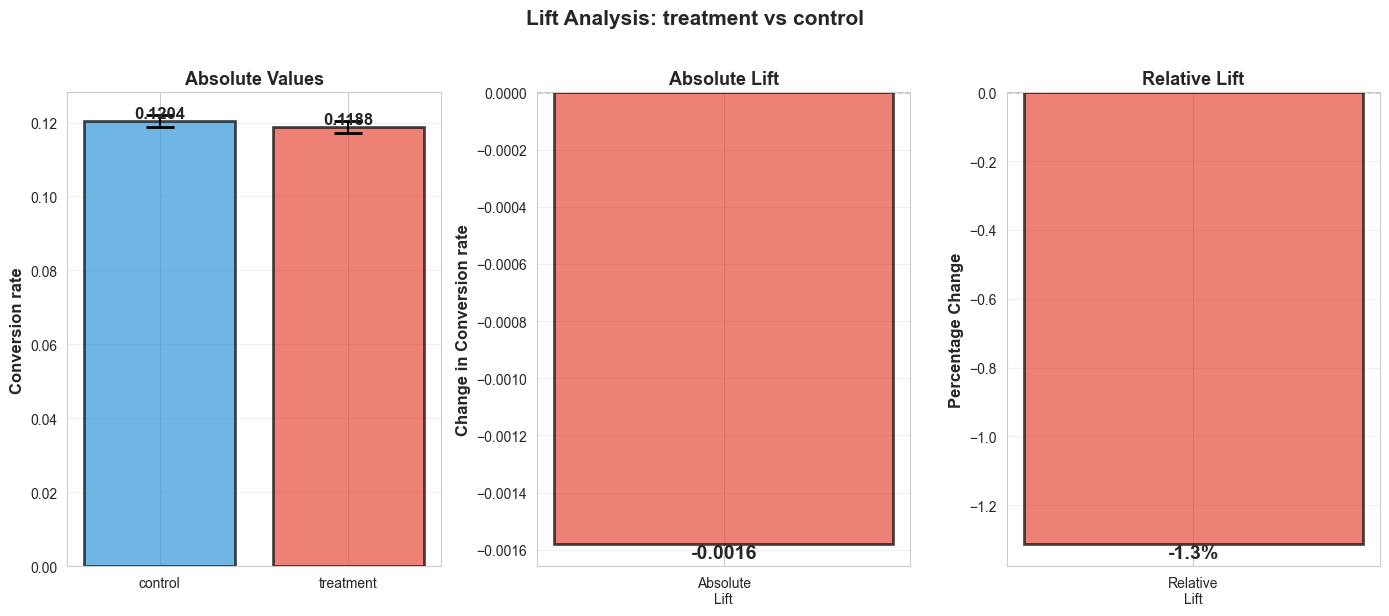

In [31]:
# plot_lift_analysis(): absolute and relative movement from control to treatment.
fig = plot_lift_analysis(
    control_metric=ab_result.control_metric,
    treatment_metric=ab_result.treatment_metric,
    control_ci=ab_result.control_ci,
    treatment_ci=ab_result.treatment_ci,
    metric_name="Conversion rate",
    control_name="control",
    treatment_name="treatment",
)


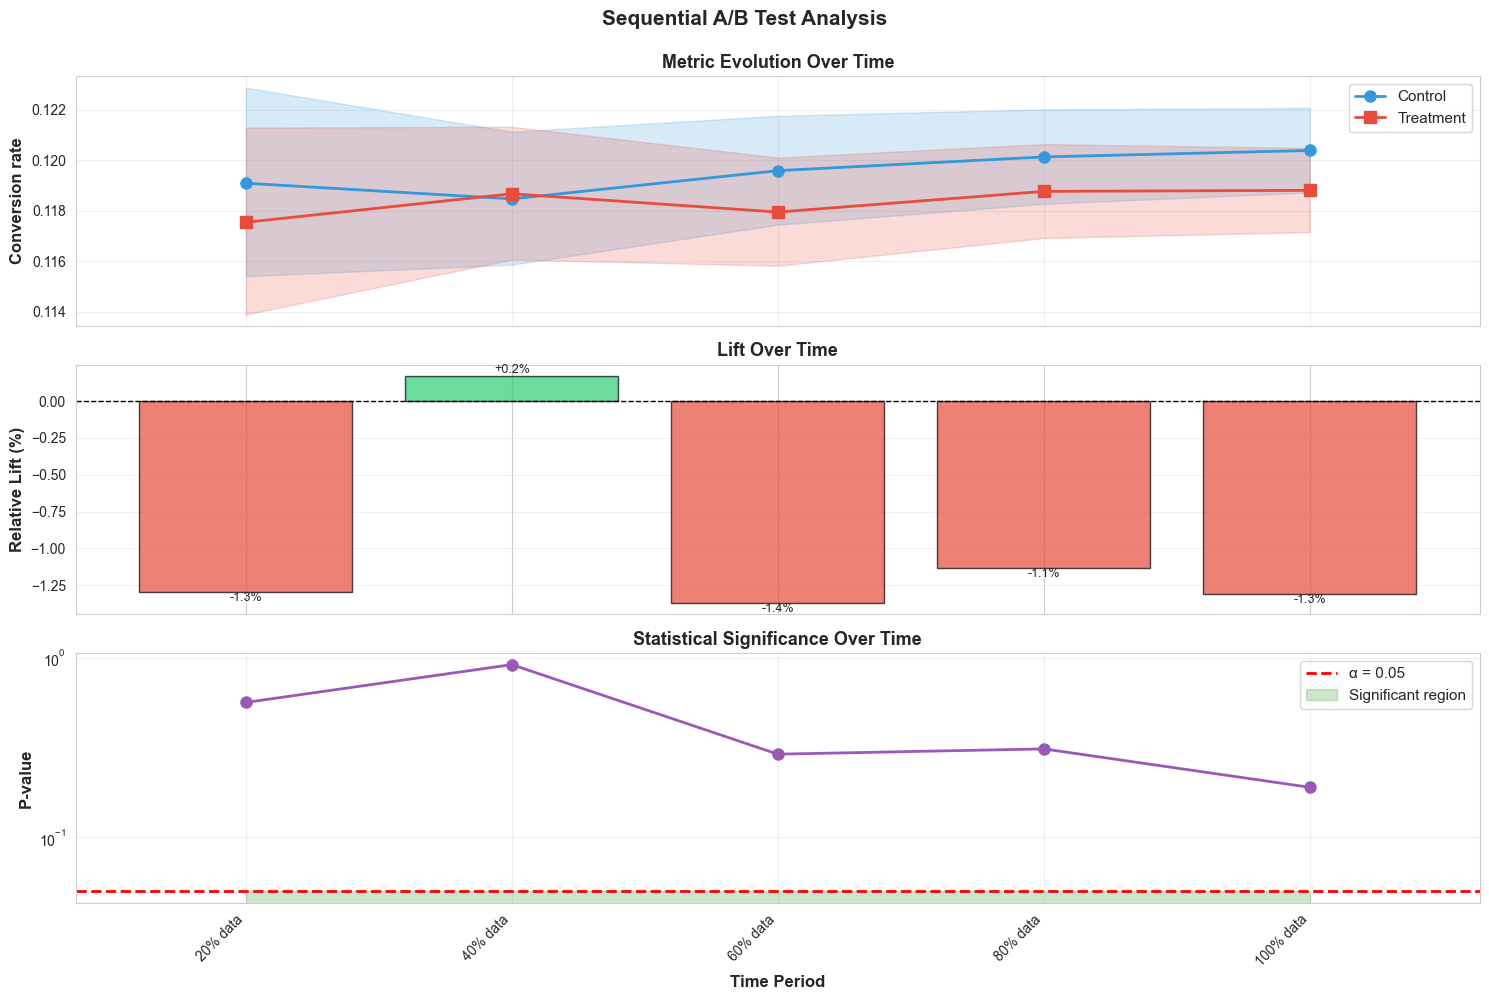

In [32]:
# plot_sequential_results(): show how an experiment evolves as data accumulates.
# The p-values here are recalculated at each cumulative checkpoint. This is for
# visualization and monitoring; formal sequential testing needs stricter rules.
ab_sorted = ab.dropna(subset=["timestamp"]).sort_values("timestamp").copy()
checkpoints = np.linspace(0.2, 1.0, 5)
seq_dates, control_metrics, treatment_metrics, control_cis, treatment_cis, p_values = [], [], [], [], [], []

for frac in checkpoints:
    partial = ab_sorted.iloc[: int(len(ab_sorted) * frac)]
    counts = partial.groupby("group")["converted"].agg(successes="sum", trials="count")
    c_success, c_trials = int(counts.loc["control", "successes"]), int(counts.loc["control", "trials"])
    t_success, t_trials = int(counts.loc["treatment", "successes"]), int(counts.loc["treatment", "trials"])
    seq_dates.append(f"{int(frac * 100)}% data")
    control_metrics.append(c_success / c_trials)
    treatment_metrics.append(t_success / t_trials)
    control_cis.append(confidence_interval_proportion(c_success, c_trials))
    treatment_cis.append(confidence_interval_proportion(t_success, t_trials))
    p_values.append(proportion_test(c_success, c_trials, t_success, t_trials).p_value)

fig = plot_sequential_results(
    dates=seq_dates,
    control_metrics=control_metrics,
    treatment_metrics=treatment_metrics,
    control_cis=control_cis,
    treatment_cis=treatment_cis,
    p_values=p_values,
    metric_name="Conversion rate",
)


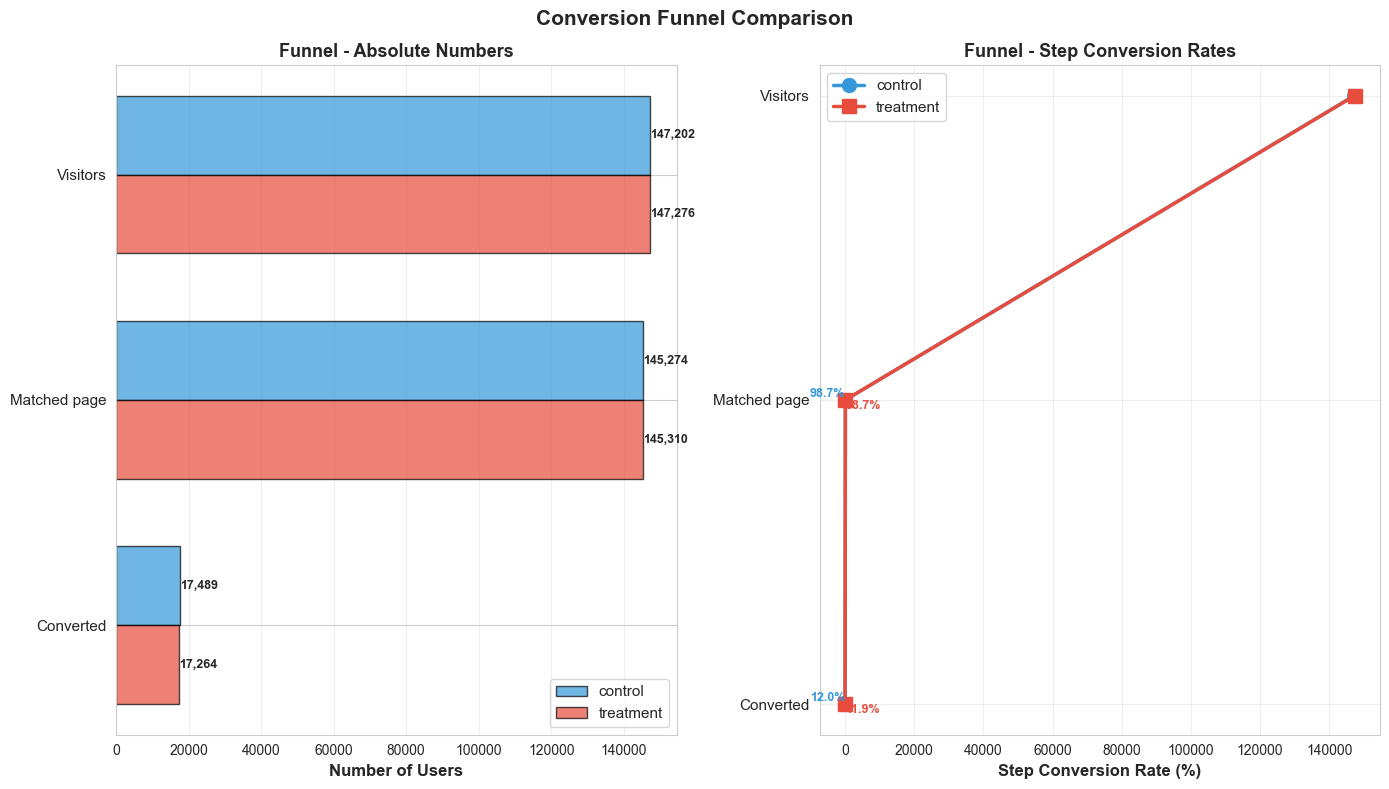

In [33]:
# plot_conversion_funnel(): compare step counts for two funnels.
# The source A/B dataset has only conversion, so we build a simple real-data
# funnel from visitors -> assigned/matched users -> converted users.
control_funnel = {
    "Visitors": int((ab_raw["group"] == "control").sum()),
    "Matched page": int((ab["group"] == "control").sum()),
    "Converted": int(ab.loc[ab["group"].eq("control"), "converted"].sum()),
}
treatment_funnel = {
    "Visitors": int((ab_raw["group"] == "treatment").sum()),
    "Matched page": int((ab["group"] == "treatment").sum()),
    "Converted": int(ab.loc[ab["group"].eq("treatment"), "converted"].sum()),
}

fig = plot_conversion_funnel(control_funnel, treatment_funnel, control_name="control", treatment_name="treatment")


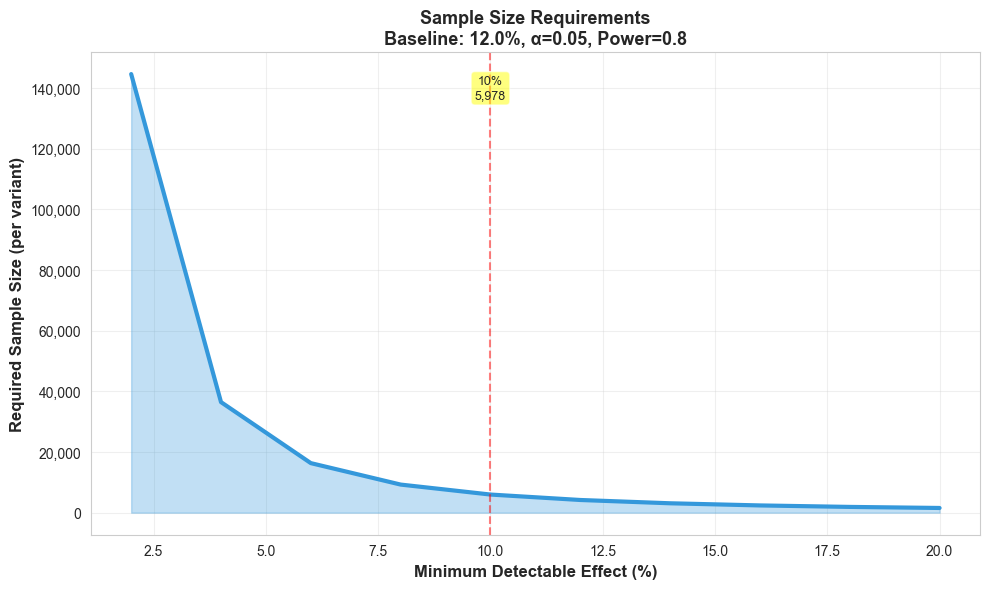

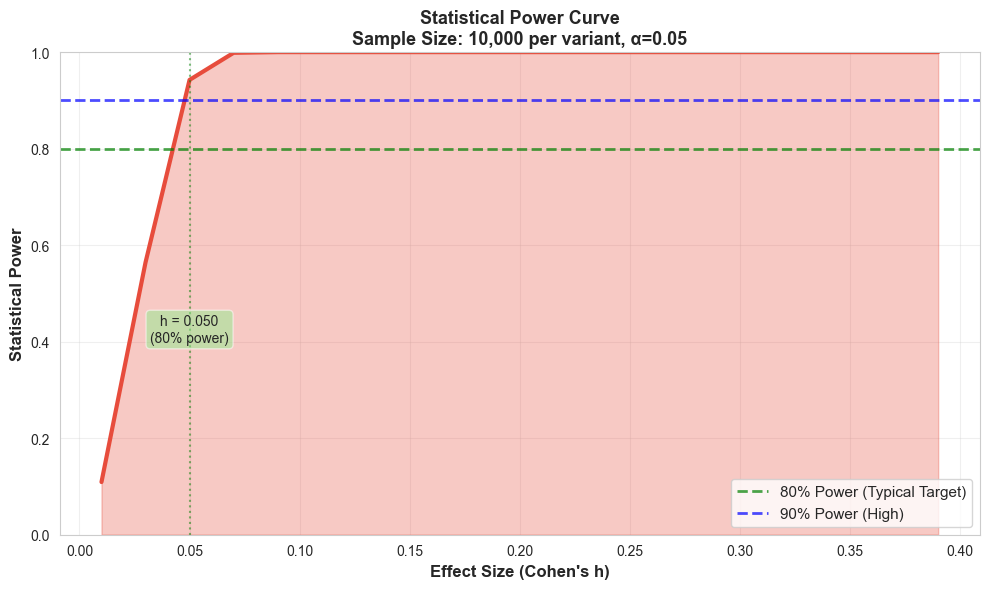

In [34]:
# plot_sample_size_curve() and plot_power_curve(): planning visuals.
fig_sample = plot_sample_size_curve(
    baseline_rate=ab_result.control_metric,
    mde_range=np.arange(0.02, 0.22, 0.02),
    power=0.80,
)
fig_power = plot_power_curve(
    baseline_rate=ab_result.control_metric,
    sample_size=10_000,
    effect_size_range=np.arange(0.01, 0.40, 0.02),
)


## Function map

| Area | Functions/classes | Best use |
| --- | --- | --- |
| Descriptive statistics | `descriptive_statistics`, `grouped_descriptive_statistics`, `frequency_table` | Summarize samples, groups, and categorical balance before testing. |
| Associations | `correlation_test`, `partial_correlation`, `correlation_matrix`, `linear_regression_test` | Quantify numeric relationships and simple linear trends. |
| Mean/proportion tests | `t_test`, `proportion_test` | Compare means or conversion rates for one or two groups. |
| Categorical tests | `chi_square_test` | Test independence or goodness of fit for count tables. |
| Non-parametric tests | `mann_whitney_test`, `wilcoxon_test`, `kruskal_wallis_test` | Compare distributions when assumptions are weak or data is ordinal/skewed. |
| Assumption checks | `normality_test`, `levene_test` | Check normality and variance equality before choosing tests. |
| Experiment workflow | `ABTest`, `MultiVariantTest`, `ABTestResult` | Run A/B and multi-variant experiments from raw data or summary counts. |
| Bayesian experiments | `bayesian_proportion_ab_test` | Estimate posterior probability that one conversion rate beats another. |
| Effect sizes | `cohens_d`, `cohens_h`, `cramers_v`, `glass_delta`, `eta_squared`, `omega_squared`, `interpret_effect_size` | Move from statistical significance to practical importance. |
| Confidence intervals | `confidence_interval_mean`, `confidence_interval_proportion`, `confidence_interval_difference` | Show uncertainty around means, proportions, and differences. |
| Resampling | `bootstrap`, `bootstrap_test` | Non-parametric uncertainty and permutation-style tests. |
| Multiple testing | `bonferroni_correction`, `holm_bonferroni_correction`, `fdr_correction`, `sidak_correction` | Control false positives when testing many variants or segments. |
| Transform helpers | `standardize`, `winsorize`, `relative_lift`, `absolute_lift`, `pooled_std` | Prepare numeric signals and report movement clearly. |
| Power planning | `two_sample_ttest_power`, `required_sample_size_two_sample` | Plan sample sizes and understand detectable effects. |
| Visual communication | `plot_ab_test_results`, `plot_confidence_intervals`, `plot_lift_analysis`, `plot_sequential_results`, `plot_conversion_funnel`, `plot_sample_size_curve`, `plot_power_curve` | Communicate experiment results, uncertainty, lift, and planning assumptions. |
